# Common

In [1433]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional
from scipy.optimize import curve_fit
import sys

np.set_printoptions(linewidth=200)

In [1434]:
@dataclass
class PlotParams:
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  int = 1
    marker:     Optional[str] = None
    markersize: int = 1
    markevery:  int = 1
    label:      str = ""
    capsize:    int = None  # размер "шапочек" на концах линий погрешности

def plot_experiment(ox, oy, params):
    plt.plot(
        ox, oy,
        linestyle   = params.linestyle,
        color       = params.color,
        linewidth   = params.linewidth,
        label       = params.label,
        marker      = params.marker,
        markersize  = params.markersize,
        markevery   = params.markevery
    )

def plot_dots(ox, oy, params):
    plt.scatter(
        ox, oy,
        color       = params.color,
        label       = params.label,
        marker      = params.marker,
        s           = params.markersize,
    )

def plot_error_bars(ox, oy, ex, ey, params):
    plt.errorbar(
        ox, oy,
        xerr = ex,
        yerr = ey,
        markersize = params.markersize,
        fmt = params.marker,
        color = params.color,
        elinewidth = params.linewidth,
        capsize=params.capsize,
        capthick=params.linewidth,
    )

def round_with_uncertainty(value, uncertainty):
    order = -int(np.floor(np.log10(uncertainty)))  # Определяем порядок округления
    rounded_value = round(value, order)
    rounded_uncertainty = round(uncertainty, order)
    return rounded_value, rounded_uncertainty

def scale_to_scientific(val, sigm):
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    scale_order = -int(np.floor(np.log10(abs(val_rounded))))  # Определяем порядок числа
    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
        varepsilon = np.abs(latex_uncertainty / latex_value * 100)
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_latex(val, sigm, parameter_name):
    val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon = scale_to_scientific(val, sigm)
    print(f"------------ {parameter_name} ------------")
    print(f"{parameter_name} = {val} ± {sigm}")
    print(f"{parameter_name}_rounded = {val_rounded} ± {sigm_rounded}")
    if scale_order != 0:
        if scale_order > 0:
            print(f"= $\\left( {latex_value:.3f} \\pm {latex_uncertainty:.3f} \\right) \\cdot 10^{{-{scale_order}}}$, \\ $ (\\varepsilon = {varepsilon:.2f} $\\%)")
        else:
            print(f"= $\\left( {latex_value:.3f} \\pm {latex_uncertainty:.3f} \\right) \\cdot 10^{{{-scale_order}}}$, \\ $ (\\varepsilon = {varepsilon:.2f} $\\%)")
    else:
        print(f"= $\\left( {val_rounded:.4f} \\pm {sigm_rounded:.4f} \\right)$, \\ $(\\varepsilon = {varepsilon:.2f}$ \\%)")
    print()

def read_data(filename, func, arguments, error_type, error_x, error_y):
    data = np.loadtxt(filename)
    xdata = data[:, 0]
    ydata = data[:, 1]

    popt, pcov = curve_fit(func, xdata, ydata)

    sigm_arr = np.sqrt(np.diag(pcov))

    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_latex(val, sigm, arg)


    # Если погрешности в процентах
    if error_type == 'percent':
        xerr = error_x * xdata  # Погрешность по X в процентах
        yerr = error_y * ydata  # Погрешность по Y в процентах
    # Если погрешности в абсолютных значениях
    elif error_type == 'absolute':
        xerr = np.full_like(xdata, error_x)  # Погрешность по X в абсолютных значениях
        yerr = np.full_like(ydata, error_y)  # Погрешность по Y в абсолютных значениях
    else:
        xerr = None
        yerr = None

    x_min = min(xdata)
    x_max = max(xdata)

    x_fit = np.linspace(x_min, x_max, 1000)
    y_fit = func(x_fit, *popt)

    return xdata, ydata, xerr, yerr, x_fit, y_fit, popt, sigm_arr

# Settings

In [1435]:
filename = 'data.txt'
filename_to_save = "calibration.pdf"

error_type = "absolute"  # "percent" or "absolute" or None
error_x = 2  # Погрешность по X
error_y = 0.0000000001  # Погрешность по Y

In [1436]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

# arguments = ['a', 'b']
# def func_axpb(x, a, b):
#     return a * x + b

arguments = ['y0', 'C', 'x0']
def func_gartman(x, y0, C, x0):
    return y0 + C / (x - x0)

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

In [1437]:
func = func_gartman

# Run

In [1438]:
xdata, ydata, xerr, yerr, x_fit, y_fit, popt, sigm_arr = read_data(filename, func, arguments, error_type, error_x, error_y)

------------ y0 ------------
y0 = 4027.4569712257703 ± 302.80502819882076
y0_rounded = 4000.0 ± 300.0
= $\left( 4.000 \pm 0.300 \right) \cdot 10^{3}$, \ $ (\varepsilon = 7.50 $\%)

------------ C ------------
C = -8403995.920630898 ± 2424437.6925172103
C_rounded = -8000000.0 ± 2000000.0
= $\left( -8.000 \pm 2.000 \right) \cdot 10^{6}$, \ $ (\varepsilon = 25.00 $\%)

------------ x0 ------------
x0 = 1291.6696929770287 ± 549.2909696604686
x0_rounded = 1300.0 ± 500.0
= $\left( 1.300 \pm 0.500 \right) \cdot 10^{3}$, \ $ (\varepsilon = 38.46 $\%)



# Graph

In [1439]:
markevery_i = 1

plot_args_dict = {
    "Fitted":  PlotParams(linestyle = "--", color = "black", linewidth = 1, marker=None, markersize=7, markevery = markevery_i, label = r'$\theta = \theta_0 + \frac{C}{\lambda - \lambda_0}$'),
    "Fitted_reversed":  PlotParams(linestyle = "--", color = "black", linewidth = 1, marker=None, markersize=7, markevery = markevery_i, label = r'$\lambda = \lambda_0 + \frac{C}{\theta - \theta_0}$'),
    "Dots": PlotParams(color = "black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
    "Error_bars": PlotParams(color = "black", linewidth=2, marker="*", markersize=9, capsize=3),
}

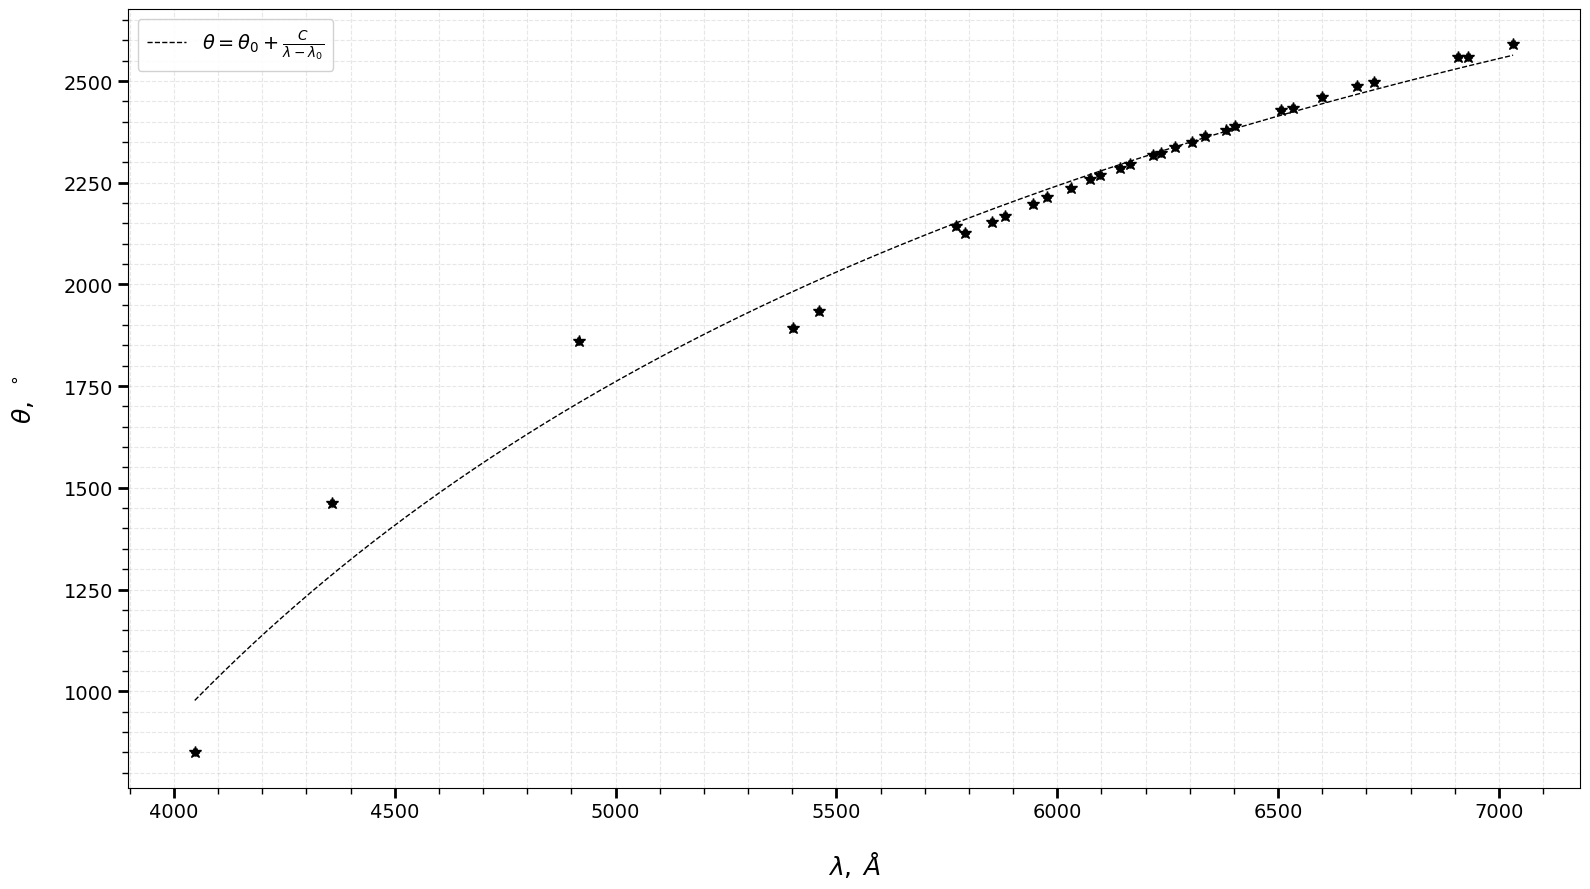

In [1440]:
plt.figure(figsize=[16, 9])

plot_experiment(x_fit, y_fit, plot_args_dict["Fitted"])

if error_type in ['percent', 'absolute']:
    plot_error_bars(xdata, ydata, xerr, yerr, plot_args_dict["Error_bars"])
else:
    plot_dots(xdata, ydata, plot_args_dict["Dots"])

# plt.title('Example', fontsize=20, pad=20)
plt.xlabel(r'$\lambda, \; \AA$', fontsize=18, labelpad=20)
plt.ylabel(r'$\theta, \; ^\circ$', fontsize=18, labelpad=20)
# plt.yscale('log')
# plt.xscale('log')
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9, borderpad=0.5)
plt.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4, width=1)
plt.tight_layout()

plt.savefig(filename_to_save)

plt.show()
plt.close()

In [1441]:
theta_data = ydata
lambda_data = xdata

theta_0 = popt[0]
C = popt[1]
lambda_0 = popt[2]

sigm_theta_0 = sigm_arr[0]
sigm_C = sigm_arr[1]
sigm_lambda_0 = sigm_arr[2]

# Если погрешности в процентах
if error_type == 'percent':
    xerr = error_x * theta_data  # Погрешность по X в процентах
    yerr = error_y * lambda_data  # Погрешность по Y в процентах
# Если погрешности в абсолютных значениях
elif error_type == 'absolute':
    xerr = np.full_like(theta_data, error_x)  # Погрешность по X в абсолютных значениях
    yerr = np.full_like(lambda_data, error_y)  # Погрешность по Y в абсолютных значениях
else:
    xerr = None
    yerr = None

x_min = min(theta_data)
x_max = max(theta_data)

x_fit = np.linspace(x_min, x_max, 10000)

lambda_from_theta = lambda theta: func_gartman(theta, popt[2], popt[1], popt[0])
y_fit = lambda_from_theta(x_fit)  # Инвертируем параметры функции

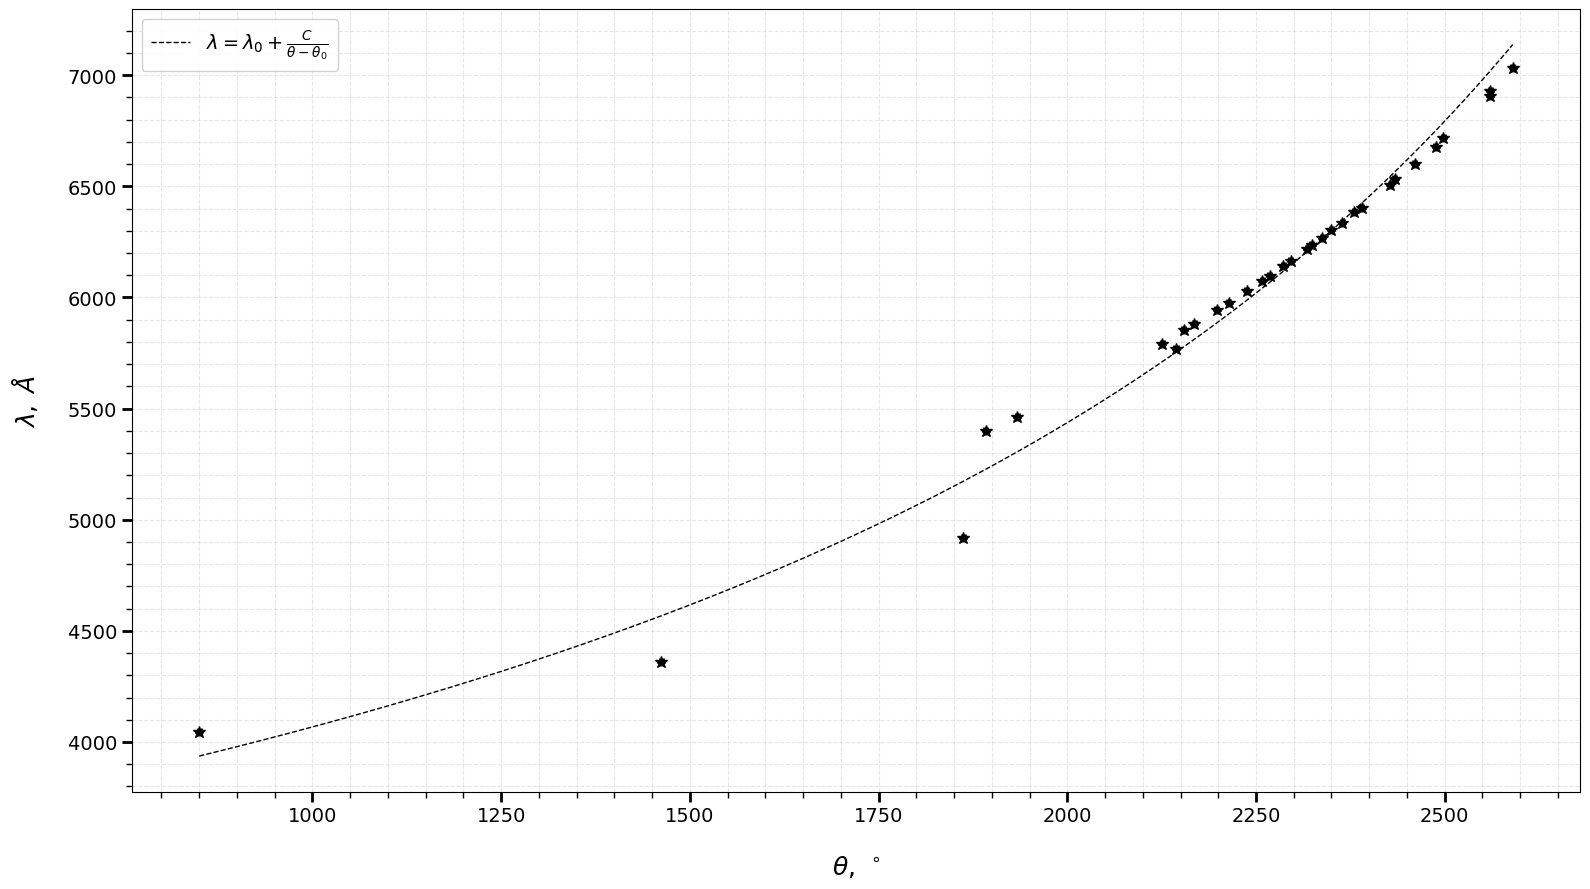

In [1442]:
plt.figure(figsize=[16, 9])

plot_experiment(x_fit, y_fit, plot_args_dict["Fitted_reversed"])

if error_type in ['percent', 'absolute']:
    plot_error_bars(theta_data, lambda_data, xerr, yerr, plot_args_dict["Error_bars"])
else:
    plot_dots(theta_data, lambda_data, plot_args_dict["Dots"])

# plt.title('Example', fontsize=20, pad=20)
plt.xlabel(r'$\theta, \; ^\circ$', fontsize=18, labelpad=20)
plt.ylabel(r'$\lambda, \; \AA$', fontsize=18, labelpad=20)
# plt.yscale('log')
# plt.xscale('log')
plt.minorticks_on()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9, borderpad=0.5)
plt.tick_params(axis='both', which='major', labelsize=14, length=7, width=2)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4, width=1)
plt.tight_layout()

plt.savefig(filename_to_save)

plt.show()
plt.close()

In [1451]:
filename_hydrogene_data = 'hydrogene_data.txt'
hydrogene_data = np.loadtxt(filename_hydrogene_data)
xdata = hydrogene_data[:, 0]
ydata = hydrogene_data[:, 1]

hydrogene_lambdas = lambda_from_theta(xdata)

def lambda_from_theta_error(theta, sigma_theta, theta_0, sigma_theta_0, C, sigma_C, lambda_0, sigma_lambda_0):
    d_theta_sigm = np.sqrt((sigma_theta)**2 + (sigma_theta_0)**2)
    d_theta_epsilon = d_theta_sigm / (theta - theta_0)
    C_epsilon = sigma_C / C
    frac_C_d_theta_epsilon = np.sqrt(d_theta_epsilon**2 + C_epsilon**2)
    frac_C_d_theta_sigm = frac_C_d_theta_epsilon * C / (theta - theta_0)
    lambda_sigma = np.sqrt(frac_C_d_theta_sigm**2 + sigma_lambda_0**2)
    return lambda_sigma


hydrogene_errors = lambda_from_theta_error(xdata, error_x, theta_0, sigm_theta_0, C, sigm_C, lambda_0, sigm_lambda_0)

for x, lam, lam_err in zip(xdata, hydrogene_lambdas, hydrogene_errors):
    print_latex(lam, lam_err, f"lambda (theta = {x})")

------------ lambda (theta = 2448.0) ------------
lambda (theta = 2448.0) = 6612.483158448521 ± 1923.1468707158187
lambda (theta = 2448.0)_rounded = 7000.0 ± 2000.0
= $\left( 7.000 \pm 2.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 28.57 $\%)

------------ lambda (theta = 1462.0) ------------
lambda (theta = 1462.0) = 4567.497748130682 ± 1159.4442058763018
lambda (theta = 1462.0)_rounded = 5000.0 ± 1000.0
= $\left( 5.000 \pm 1.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 20.00 $\%)

------------ lambda (theta = 826.0) ------------
lambda (theta = 826.0) = 3916.7232220935502 ± 967.915659136836
lambda (theta = 826.0)_rounded = 3900.0 ± 1000.0
= $\left( 3.900 \pm 1.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 25.64 $\%)

------------ lambda (theta = 420.0) ------------
lambda (theta = 420.0) = 3621.287478487391 ± 889.7350688685827
lambda (theta = 420.0)_rounded = 3600.0 ± 900.0
= $\left( 3.600 \pm 0.900 \right) \cdot 10^{3}$, \ $ (\varepsilon = 25.00 $\%)



In [1444]:
Z = 1
n = 2
m_arr = np.array([3, 4, 5, 6])

def R(n, m, lambda_mn, Z):
    return 1/ (lambda_mn * (1/n**2 - 1/m**2) * Z**2)

R_values = R(n, m_arr, hydrogene_lambdas * 1e-10, Z)
R_errors = R_values * (hydrogene_errors / hydrogene_lambdas)

for m, R_val, R_err in zip(m_arr, R_values, R_errors):
    print_latex(R_val, R_err, f"R_{{{m},{n}}}")

R_avarage = np.mean(R_values)
R_avarage_error = np.std(R_values) / np.sqrt(len(R_values) - 1)

print_latex(R_avarage, R_avarage_error, "R_avarage")

------------ R_{3,2} ------------
R_{3,2} = 10888496.541274106 ± 3166764.6704546744
R_{3,2}_rounded = 11000000.0 ± 3000000.0
= $\left( 1.100 \pm 0.300 \right) \cdot 10^{7}$, \ $ (\varepsilon = 27.27 $\%)

------------ R_{4,2} ------------
R_{4,2} = 11676707.088725071 ± 2964093.498081714
R_{4,2}_rounded = 12000000.0 ± 3000000.0
= $\left( 1.200 \pm 0.300 \right) \cdot 10^{7}$, \ $ (\varepsilon = 25.00 $\%)

------------ R_{5,2} ------------
R_{5,2} = 12157879.155319655 ± 3004501.709476716
R_{5,2}_rounded = 12000000.0 ± 3000000.0
= $\left( 1.200 \pm 0.300 \right) \cdot 10^{7}$, \ $ (\varepsilon = 25.00 $\%)

------------ R_{6,2} ------------
R_{6,2} = 12426519.647315176 ± 3053143.496582872
R_{6,2}_rounded = 12000000.0 ± 3000000.0
= $\left( 1.200 \pm 0.300 \right) \cdot 10^{7}$, \ $ (\varepsilon = 25.00 $\%)

------------ R_avarage ------------
R_avarage = 11787400.6081585 ± 337393.07896787283
R_avarage_rounded = 11800000.0 ± 300000.0
= $\left( 1.180 \pm 0.030 \right) \cdot 10^{7}$, \ $ (\

In [1445]:
h = 6.62607015e-34  # Планковская постоянная, Дж·с
c = 299792458  # Скорость света в вакууме, м/с
e = 1.602176634e-19  # Заряд электрона, К

filename_iod_data = 'iod_data.txt'
iod_data = np.loadtxt(filename_iod_data)
theta_data = iod_data

lambda_data = lambda_from_theta(theta_data)
lambda_errors = lambda_from_theta_error(theta_data, 2, theta_0, sigm_theta_0, C, sigm_C, lambda_0, sigm_lambda_0)

lambda_1 = lambda_data[0]
lambda_15 = lambda_data[1]
lambda_gr = lambda_data[2]

lambda_1_error = lambda_errors[0]
lambda_15_error = lambda_errors[1]
lambda_gr_error = lambda_errors[2]

for ld, lam, lam_err in zip(theta_data, lambda_data, lambda_errors):
    print_latex(lam, lam_err, f"\\lambda_{{{ld}}}")

------------ \lambda_{2328.0} ------------
\lambda_{2328.0} = 6236.776314046307 ± 1764.4484835747708
\lambda_{2328.0}_rounded = 6000.0 ± 2000.0
= $\left( 6.000 \pm 2.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 33.33 $\%)

------------ \lambda_{2240.0} ------------
\lambda_{2240.0} = 5993.319050649541 ± 1666.0892184731508
\lambda_{2240.0}_rounded = 6000.0 ± 2000.0
= $\left( 6.000 \pm 2.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 33.33 $\%)

------------ \lambda_{1650.0} ------------
\lambda_{1650.0} = 4826.537420277247 ± 1242.7142315859865
\lambda_{1650.0}_rounded = 5000.0 ± 1000.0
= $\left( 5.000 \pm 1.000 \right) \cdot 10^{3}$, \ $ (\varepsilon = 20.00 $\%)



In [1453]:
h_nu_15 = h * c / (lambda_15 * 1e-10)
h_nu_15_error = h_nu_15 * (lambda_15_error / lambda_15)
h_nu_1 = h * c / (lambda_1 * 1e-10)
h_nu_1_error = h_nu_1 * (lambda_1_error / lambda_1)
h_nu_gr = h * c / (lambda_gr * 1e-10)
h_nu_gr_error = h_nu_gr * (lambda_gr_error / lambda_gr)

h_nu_2 = (h_nu_15 - h_nu_1) / 5
h_nu_2_error = np.sqrt(h_nu_15_error**2 + h_nu_1_error**2) / 5

print(h_nu_2 / e, h_nu_2_error / e, h_nu_2_error / h_nu_2 * 100)

0.016150705738520572 0.16087600090455265 996.0927002765709


In [1448]:
h_nu_1_ref_eV = 0.027

h_nu_el = h_nu_1 / e - 1/2 * (h_nu_2 / e) + 3/2 * h_nu_1_ref_eV

print(h_nu_el)

2.020377913210946


In [1450]:
Ea = 0.94 # eV

D1 = h_nu_gr / e - Ea
D1_sigm = h_nu_gr_error / e

D2 = h_nu_gr / e - h_nu_el # 

print(D1, D2)

1.6288021792251706 0.5484242660142247
